In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import graphviz
import shutil

In [2]:
# Load your dataset
df = pd.read_csv("C:\\Users\\chaya\\Downloads\\heart.csv")

# Preview
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
# Assuming 'target' is the label column
X = df.drop("target", axis=1)
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

# Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9853658536585366


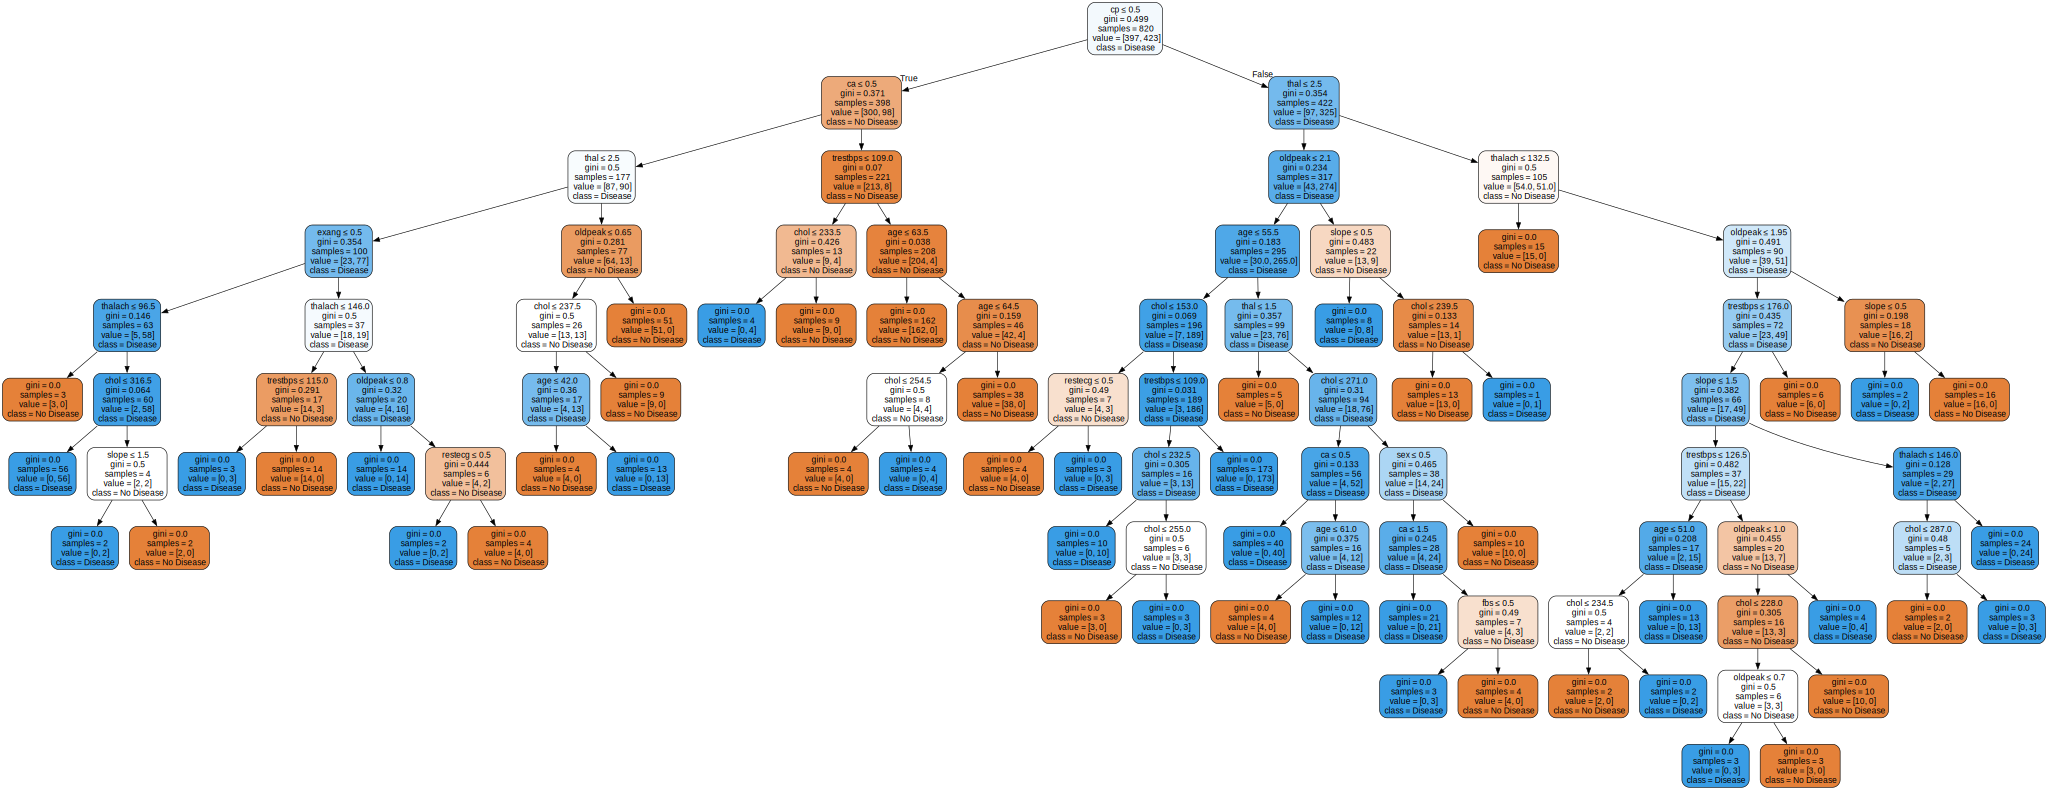

In [5]:
if shutil.which("dot") is None:
    raise EnvironmentError(
        "Graphviz 'dot' executable not found. Install Graphviz and add it to PATH."
    )

dot_data = export_graphviz(
    dt,
    out_file=None,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    special_characters=True,
)

graph = graphviz.Source(dot_data)
graph


In [6]:
dt_limited = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_limited.fit(X_train, y_train)

y_pred_limited = dt_limited.predict(X_test)

print("Limited Tree Accuracy:", accuracy_score(y_test, y_pred_limited))

Limited Tree Accuracy: 0.7804878048780488


In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9853658536585366


In [8]:
importances = rf.feature_importances_
feature_names = X.columns

# Display
for name, score in zip(feature_names, importances):
    print(f"{name}: {score:.4f}")

age: 0.0779
sex: 0.0287
cp: 0.1351
trestbps: 0.0712
chol: 0.0748
fbs: 0.0084
restecg: 0.0186
thalach: 0.1222
exang: 0.0576
oldpeak: 0.1219
slope: 0.0458
ca: 0.1273
thal: 0.1105


In [9]:
scores = cross_val_score(rf, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [1.         1.         1.         1.         0.98536585]
Mean accuracy: 0.9970731707317073
